# Home Credit Default Risk

Ноутбук с базовой загрузкой данных, feature engineering и сравнением baseline-моделей.


In [81]:
import lightgbm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from src.data_loader import load_core_tables
from src.features import merge_bureau_features, merge_bureau_balance_features, merge_credit_credit_features, \
    merge_installments_payments_features
from src.features import merge_POS_CASH_BALANCE_features
from src.features import merge_previous_application_features


In [82]:
tables = load_core_tables('.')
train = merge_bureau_features(tables['application_train'], tables['bureau'])
train = merge_bureau_balance_features(train, tables['bureau'], tables['bureau_balance'])
train = merge_credit_credit_features(train, tables['credit_card_balance'])
train = merge_installments_payments_features(train, tables['installments_payments'])
train = merge_POS_CASH_BALANCE_features(train,tables['POS_CASH_balance'])
train = merge_previous_application_features(train,tables['previous_application'])

In [83]:
train.shape

(307511, 236)

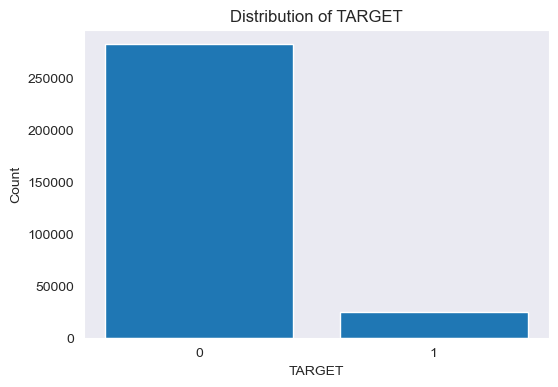

<Figure size 600x400 with 0 Axes>

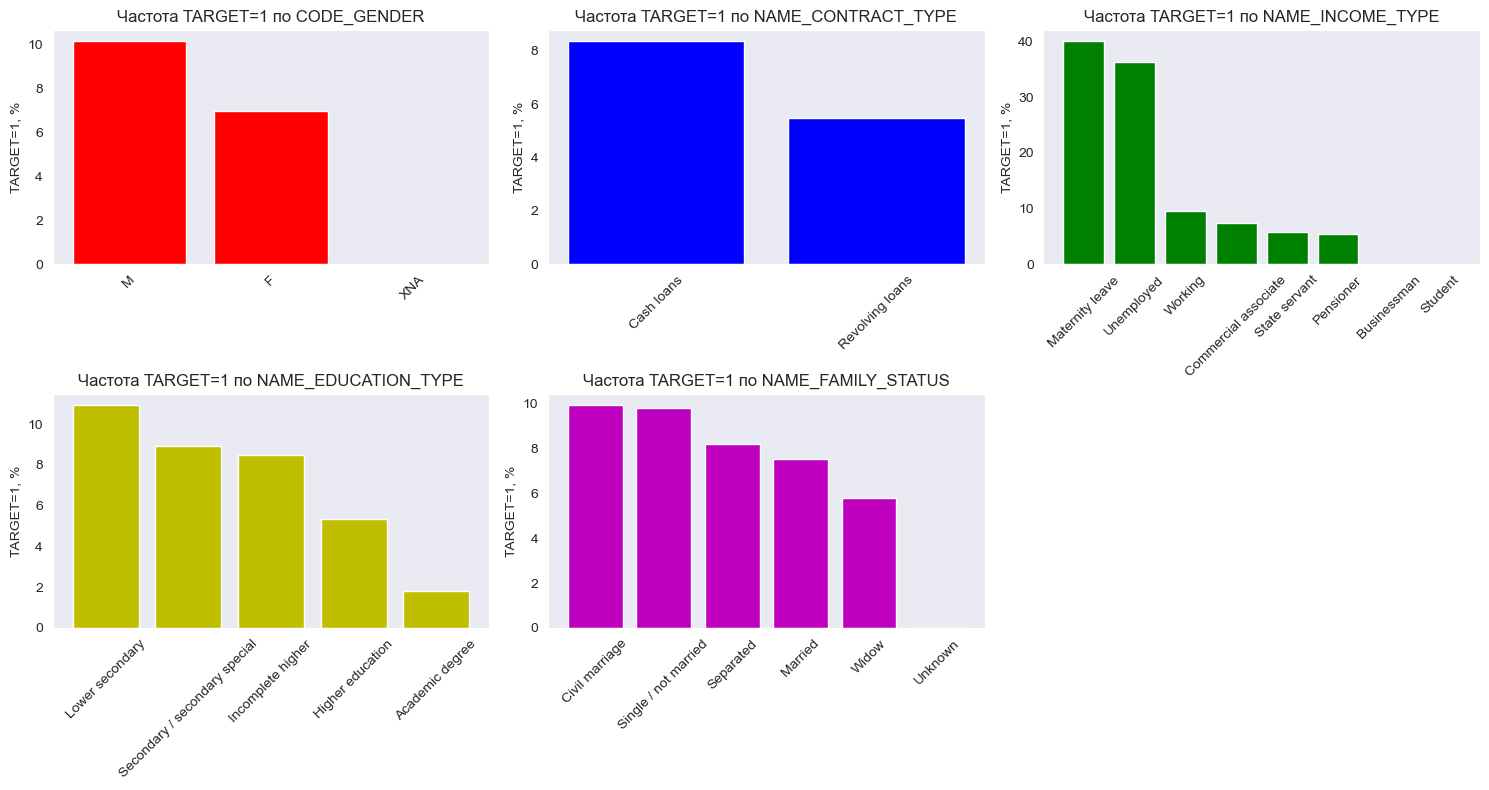

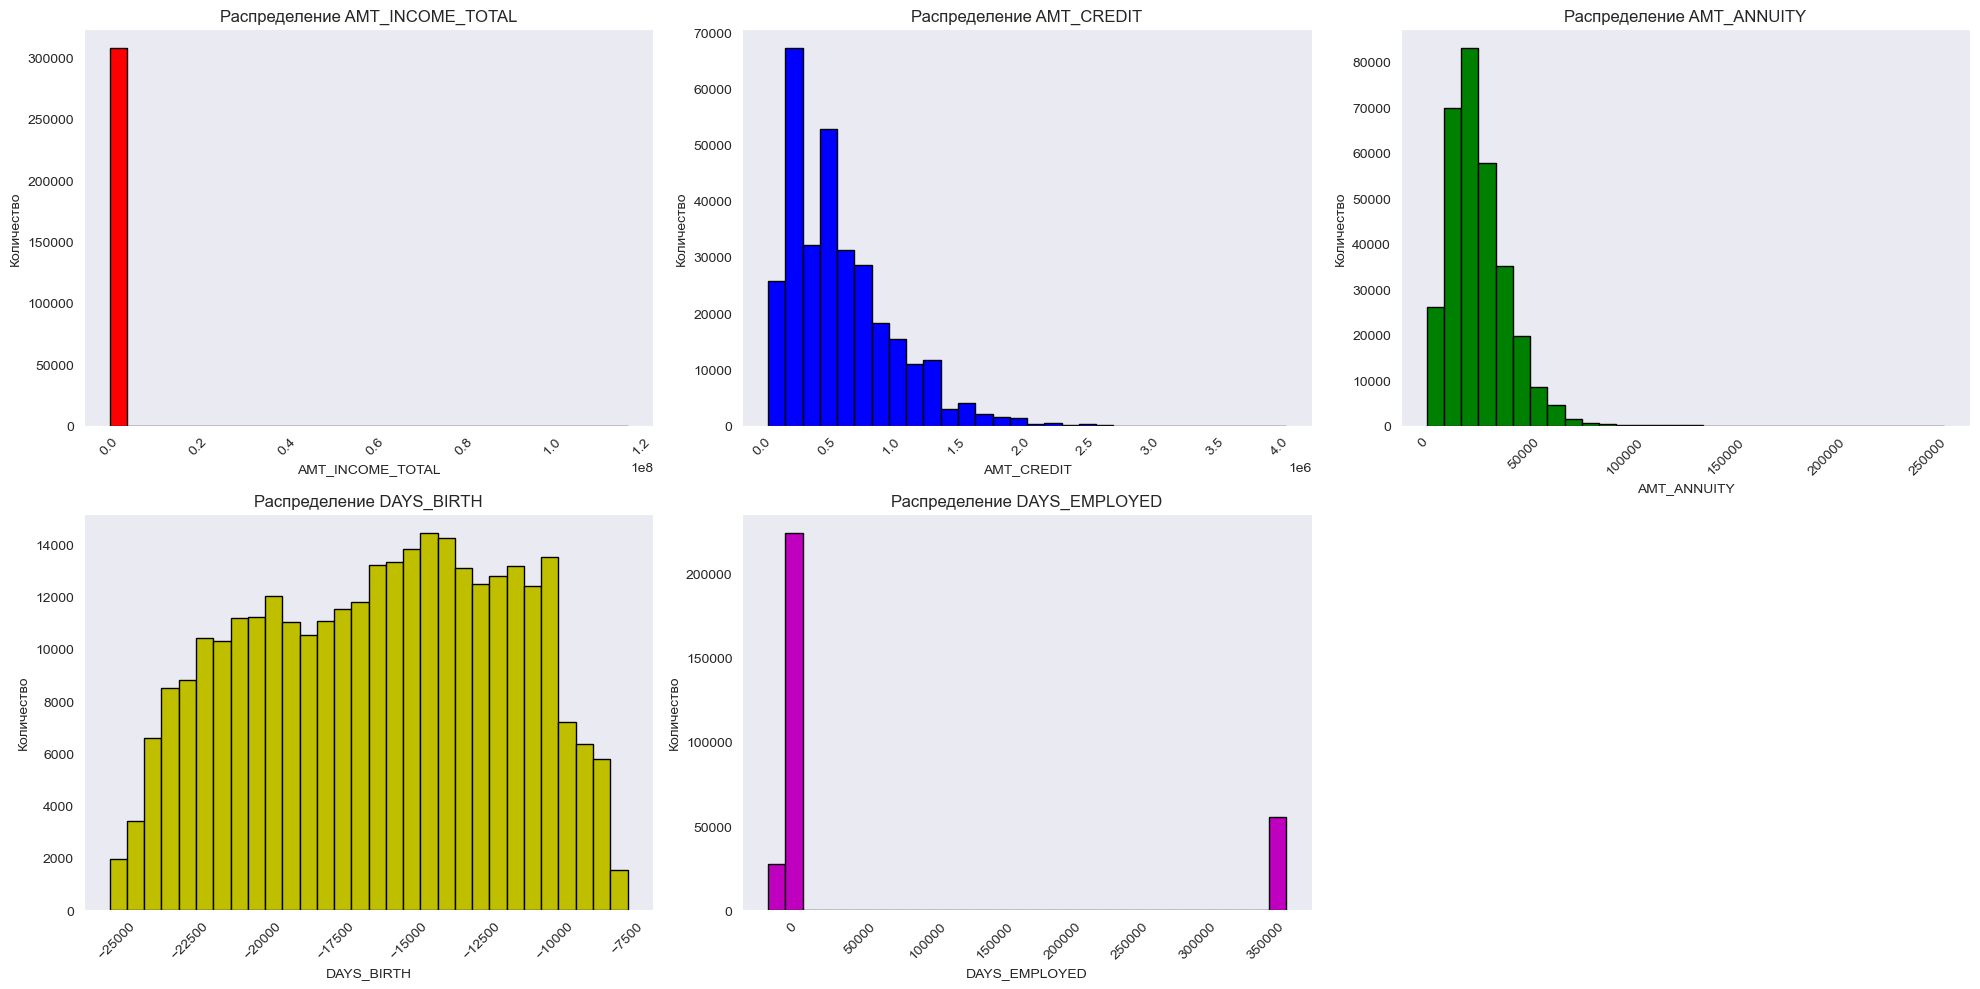

In [84]:
target_counts = train['TARGET'].value_counts()
import seaborn as sns

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title('Distribution of TARGET')
plt.xlabel('TARGET')
plt.ylabel('Count')
plt.grid()
plt.show()

plt.figure(figsize=(6, 4))
cols = [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS"
]
color = ['r', 'b', 'g', 'y', 'm', 'w']
i = 0
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()
for j, col in enumerate(cols):
    rate = (train.groupby(col)["TARGET"].mean() * 100).sort_values(ascending=False)
    color_current = color[i]
    axes[j].bar(rate.index, rate.values, color=color_current)
    axes[j].set_title(f"Частота TARGET=1 по {col}")
    axes[j].set_ylabel("TARGET=1, %")
    axes[j].set_xlabel("")
    axes[j].tick_params(axis="x", rotation=45)
    axes[j].grid()
    i += 1
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
col_money = ['AMT_INCOME_TOTAL',
             'AMT_CREDIT',
             'AMT_ANNUITY',
             'DAYS_BIRTH',
             'DAYS_EMPLOYED']
axes = axes.flatten()
for j, col in enumerate(col_money):
    values = train[col]
    color_current = color[j]
    axes[j].hist(values, bins=30, color=color_current, edgecolor="black")
    axes[j].set_title(f"Распределение {col}")
    axes[j].set_ylabel("Количество")
    axes[j].set_xlabel(col)
    axes[j].tick_params(axis="x", rotation=45)
    axes[j].grid()
plt.tight_layout()
fig.delaxes(axes[5])
plt.show()

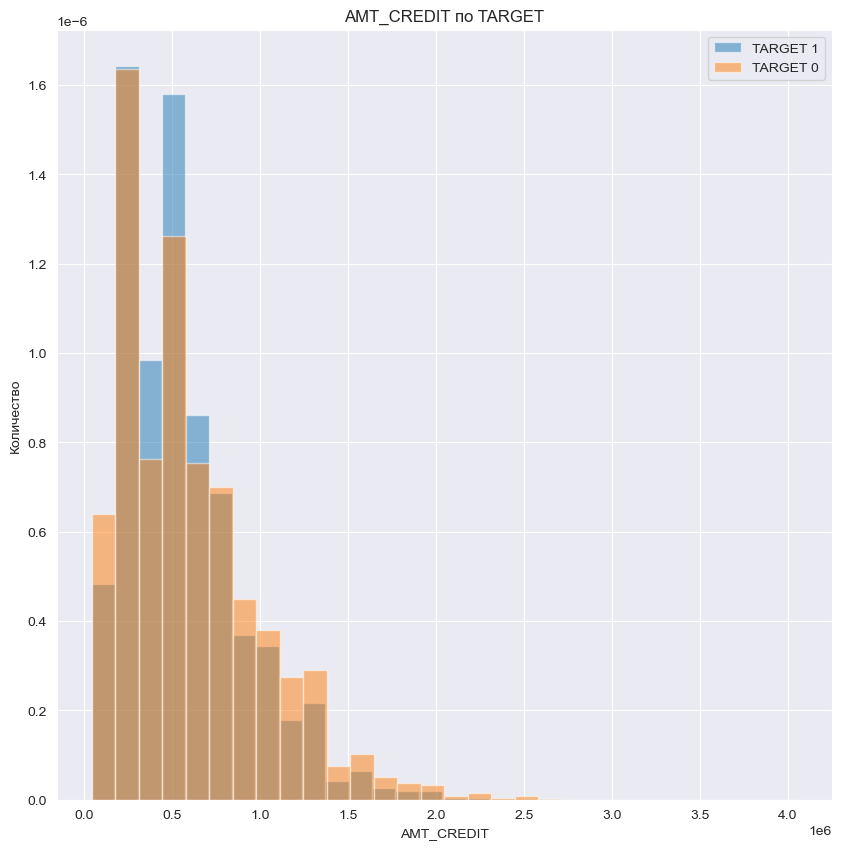

In [85]:
plt.figure(figsize=(10, 10))
plt.hist(train[train['TARGET'] == 1]['AMT_CREDIT'], bins=30, alpha=0.5, label='TARGET 1', density=True)
plt.hist(train[train['TARGET'] == 0]['AMT_CREDIT'], bins=30, alpha=0.5, label='TARGET 0', density=True)
plt.title("AMT_CREDIT по TARGET")
plt.xlabel("AMT_CREDIT")
plt.ylabel("Количество")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\myska\AppData\Local\Temp\ipykernel_22512\390797134.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = train.groupby(credit_bins)["TARGET"].mean() * 100


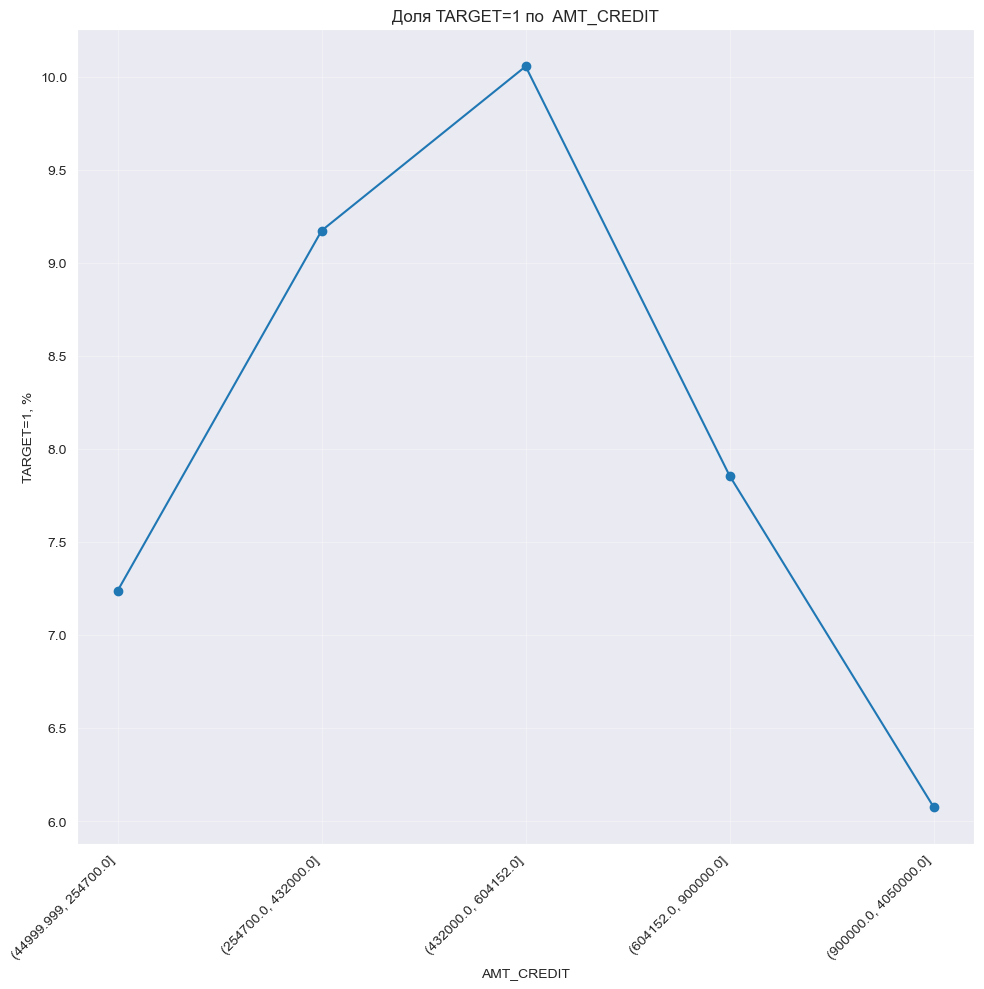

In [86]:
credit_bins = pd.qcut(train["AMT_CREDIT"], q=5)
rate = train.groupby(credit_bins)["TARGET"].mean() * 100
plt.figure(figsize=(10, 10))
plt.plot(rate.index.astype(str), rate.values, marker="o")
plt.title("Доля TARGET=1 по  AMT_CREDIT")
plt.xlabel("AMT_CREDIT")
plt.ylabel("TARGET=1, %")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

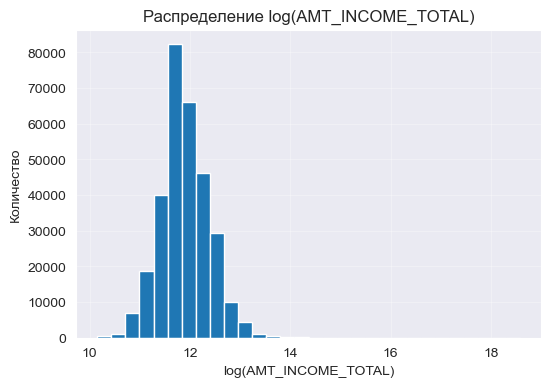

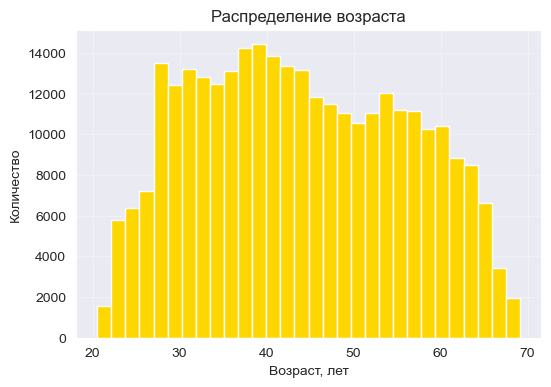

In [87]:
train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].replace(365243, np.nan)
plt.figure(figsize=(6, 4))
plt.hist(np.log1p(train["AMT_INCOME_TOTAL"].dropna()), bins=30)
plt.title("Распределение log(AMT_INCOME_TOTAL)")
plt.xlabel("log(AMT_INCOME_TOTAL)")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.show()
train['age_years'] = -train["DAYS_BIRTH"] / 365

plt.figure(figsize=(6, 4))
plt.hist(train['age_years'].dropna(), bins=30, color="gold")
plt.title("Распределение возраста")
plt.xlabel("Возраст, лет")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.show()

## Обработка пропусков и подготовка признаков

Заполнение пропусков и финализация набора признаков перед моделированием.


In [88]:
few_passes = ['DAYS_LAST_PHONE_CHANGE',
              'CNT_FAM_MEMBERS',
              'AMT_ANNUITY',
              'AMT_GOODS_PRICE']
train[few_passes] = train[few_passes].fillna(train[few_passes].mean())
social_columns = ['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
                  'DEF_60_CNT_SOCIAL_CIRCLE']
train[social_columns] = train[social_columns].fillna(0)
amt_req = [col for col in train.columns if col.startswith('AMT_REQ_CREDIT_BUREAU')]
for i in range(len(amt_req)):
    train[f'have_checked_req_credit_{i}'] = (train[amt_req[i]] > 0).astype(int)
train[amt_req] = train[amt_req].fillna(0)

In [89]:
ext_sour = [col for col in train.columns if col.startswith('EXT_SOURCE_')]
for ext in ext_sour:
    train[ext] = train[ext].fillna(train[ext].mean())
past_end = [col for col in train.columns if col.startswith('PAST_END')]
early_close = [col for col in train.columns if col.startswith('EARLY_CLOSE')]
ins_col = [col for col in train.columns if col.startswith('INS')]
pos_col = [col for col in train.columns if col.startswith('POS')]
approv_col = [col for col in train.columns if col.startswith('APPROVED')]
prev_col = [col for col in train.columns if col.startswith('PREV')]
train[pos_col] = train[pos_col].fillna(0)
train[approv_col]=train[approv_col].fillna(0)
train[prev_col]=train[prev_col].fillna(0)
train[ins_col] = train[ins_col].fillna(0)
credit_cols = [
    'CREDIT_COUNT', 'CREDIT_MEAN', 'CREDIT_MAX',
    'ACTIVE_CREDIT_SUM', 'ACTIVE_CREDIT_MEAN',
    'CREDIT_DAY_OVERDUE_SUM', 'CREDIT_DAY_OVERDUE_MAX',
    'CREDIT_DAY_OVERDUE_MIN', 'CREDIT_DAY_OVERDUE_MEAN',
    'DAYS_CREDIT_ENDDATE_MIN', 'DAYS_CREDIT_ENDDATE_MAX',
    'DAYS_CREDIT_ENDDATE_MEAN', 'DAYS_ENDDATE_FACT_MEAN'
]
bureau_features = [
    'CREDIT_SUM',
    'DAYS_CREDIT_MOST_RECENT',
    'DAYS_CREDIT_MEAN',
    'DAYS_CREDIT_OLDEST',
    'DAYS_CREDIT_ENDDATE_SUM'
]
train['OWN_CAR_AGE'] = train['OWN_CAR_AGE'].fillna(0)
train[credit_cols] = train[credit_cols].fillna(0)
train[bureau_features] = train[bureau_features].fillna(0)
for past in past_end:
    train[past] = train[past].fillna(0)
for early in early_close:
    train[early] = train[early].fillna(0)

In [90]:
categorical = [
    'NAME_TYPE_SUITE',
    'OCCUPATION_TYPE',
    'EMERGENCYSTATE_MODE',
    'HOUSETYPE_MODE',
    'WALLSMATERIAL_MODE',
    'FONDKAPREMONT_MODE'
]
loan_types = [
    'Another type of loan',
    'Car loan',
    'Loan for business development',
    'Consumer credit',
    'Credit card',
    'Interbank credit',
    'Loan for the purchase of equipment',
    'Loan for purchase of shares (margin lending)',
    'Loan for working capital replenishment',
    'Cash loan (non-earmarked)',
    'Real estate loan',
    'Mortgage',
    'Mobile operator loan',
    'Unknown type of loan',
    'Microloan'
]
train['HAS_POS_HISTORY'] = train['POS_PREV_CREDIT_COUNT'].notna().astype(int)
train['HAS_PREV_HISTORY'] = train['PREV_APPLICATION_COUNT'].notna().astype(int)
train['HAS_APPROVED_HISTORY'] = train['APPROVED_AMT_CREDIT_MEAN'].notna().astype(int)

housing = [
    'TOTALAREA_MODE',

    'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE',

    'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE',
    'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE',

    'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE',
    'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE',

    'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE',
    'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE',

    'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE',
    'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE',
    'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE',

    'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE',
    'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE'
]
train[categorical] = train[categorical].fillna('Unknown')
train[loan_types] = train[loan_types].fillna(0)
train[housing] = train[housing].fillna(-1)
bb_cols = [col for col in train.columns if col.startswith("BB_")]
train[bb_cols] = train[bb_cols].fillna(0)
train[bb_cols] = train[bb_cols].fillna(0)
credit_card_cols = [
    "balance_to_limit_mean",
    "balance_to_limit_max",
    "dpd_mean",
    "dpd_max",
    "payment_to_min_mean",
    "payment_to_min_max",
    "payment_to_balance_mean",
    "payment_to_balance_max",
    "drawings_to_limit_mean",
    "drawings_to_limit_max",
]

train[credit_card_cols] = train[credit_card_cols].fillna(0)
train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].fillna(train["DAYS_EMPLOYED"].median())
train = train.copy()
train['credit_income_credit'] = train['AMT_CREDIT'] / train[
    'AMT_INCOME_TOTAL']
train['annuity_to_income'] = train['AMT_ANNUITY'] / train[
    'AMT_INCOME_TOTAL']
train['income_for_person'] = train['AMT_INCOME_TOTAL'] / train[
    'CNT_FAM_MEMBERS']
train['EXT_SOURCE_MEAN'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
train['EXT_SOURCE_MAX'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
train['EXT_SOURCE_MIN'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
train['EXT_SOURCE_STD'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

C:\Users\myska\AppData\Local\Temp\ipykernel_22512\3343279177.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['HAS_POS_HISTORY'] = train['POS_PREV_CREDIT_COUNT'].notna().astype(int)
C:\Users\myska\AppData\Local\Temp\ipykernel_22512\3343279177.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['HAS_PREV_HISTORY'] = train['PREV_APPLICATION_COUNT'].notna().astype(int)
C:\Users\myska\AppData\Local\Temp\ipykernel_22512\3343279177.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result 

In [91]:
train.isnull().sum().sort_values(ascending=False).head(30)
train =train.replace([np.inf, -np.inf], np.nan).fillna(0)



## Подготовка выборок

Разделение данных и one-hot encoding категориальных признаков.


In [92]:
def get_train_test_data(train: pd.DataFrame):
    Y = train['TARGET']
    X = train.drop('TARGET', axis=1)
    cat_cols = X.select_dtypes(include=['object']).columns

    x_train, x_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42, stratify=Y
    )
    x_train_for_catboost = x_train
    x_test_for_catboost = x_test
    y_train_for_catboost = y_train
    y_test_for_catboost = y_test
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    x_train_ohe = ohe.fit_transform(x_train[cat_cols])
    x_train_ohe_df = pd.DataFrame(x_train_ohe, columns=ohe.get_feature_names_out(cat_cols), index=x_train.index)
    x_test_ohe = ohe.transform(x_test[cat_cols])
    x_test_ohe_df = pd.DataFrame(
        x_test_ohe,
        columns=ohe.get_feature_names_out(cat_cols),
        index=x_test.index
    )

    x_train = x_train.drop(columns=cat_cols)
    x_test = x_test.drop(columns=cat_cols)

    x_train = pd.concat([x_train, x_train_ohe_df], axis=1)
    x_test = pd.concat([x_test, x_test_ohe_df], axis=1)
    print(x_train.shape, x_test.shape)
    return x_train, x_test, y_train, y_test, x_train_for_catboost, x_test_for_catboost, y_train_for_catboost, y_test_for_catboost


In [93]:
models = {
    "LogisticRegression": {
        "model": LogisticRegression(
            random_state=42,
            max_iter=1000
        ),
        "scaled": True,
    },

    "RandomForest": {
        "model": RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
            verbose=True
        ),
        "scaled": False,
    },

    "LightGBM": {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=100
        ),
        "scaled": False,
    },

    "CatBoost": {
        "model": CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=6,
            eval_metric="PRAUC",
            random_seed=42,
            verbose=100
        ),
        "scaled": False,
    },
}
x_train, x_test, y_train, y_test, x_train_for_catboost, x_test_for_catboost, y_train_for_catboost, y_test_for_catboost = get_train_test_data(
    train)
x_train_copy = x_train.copy()

(246008, 382) (61503, 382)


Сейчас обучаем LogisticRegression


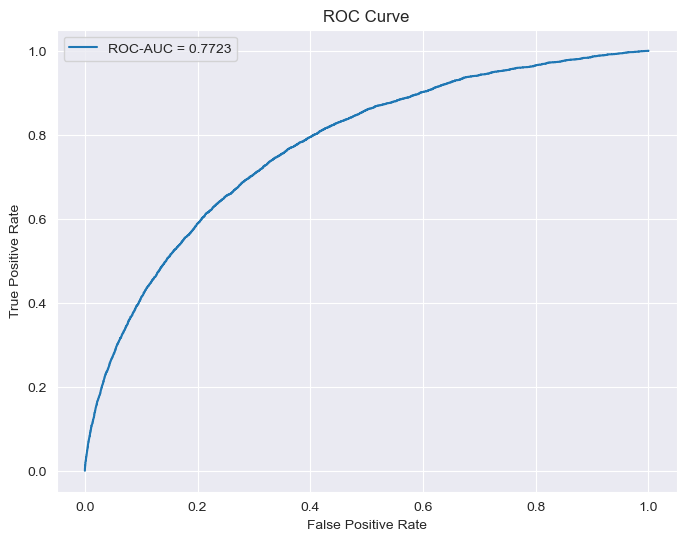

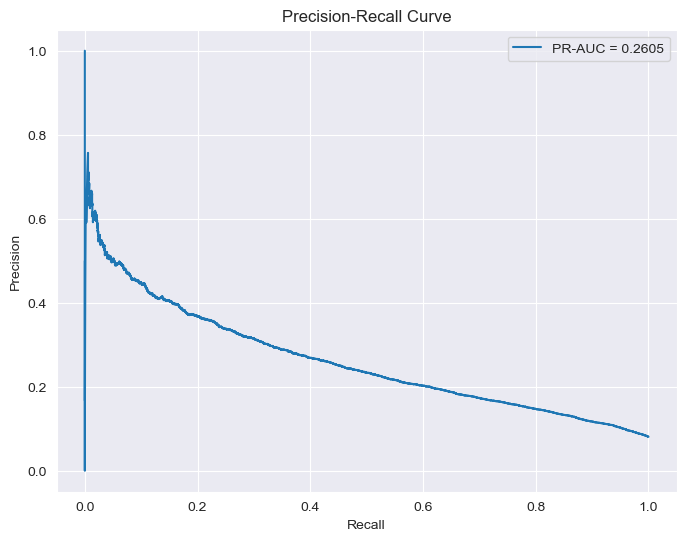

Сейчас обучаем RandomForest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   26.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   29.9s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished


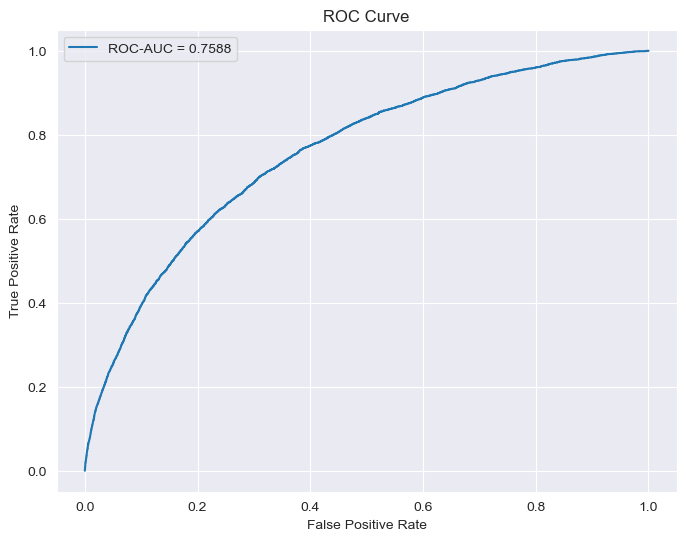

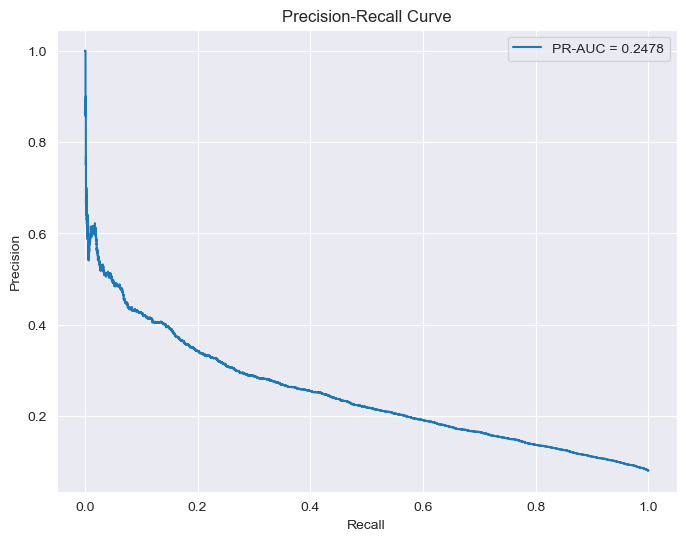

Сейчас обучаем LightGBM
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.934986
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.536083
[LightGBM] [Debug] init for col-wise cost 0.053927 seconds, init for row-wise cost 0.227411 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.253922 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33172
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 363
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained

C:\Users\myska\anaconda3\envs\PythonProject1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\myska\anaconda3\envs\PythonProject1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


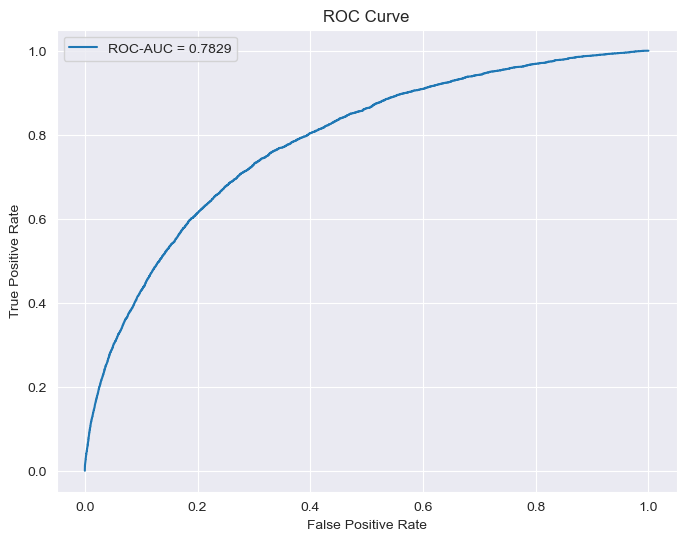

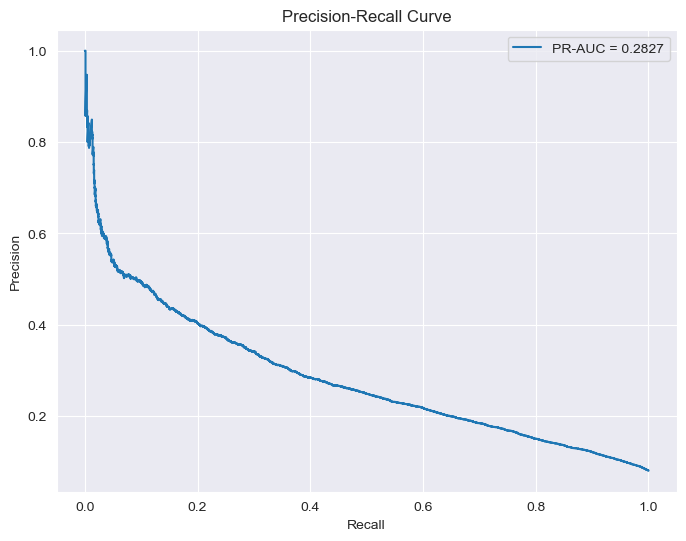

Сейчас обучаем CatBoost
0:	learn: 0.1413489	total: 267ms	remaining: 2m 12s
100:	learn: 0.2470555	total: 26.6s	remaining: 1m 45s
200:	learn: 0.2689009	total: 58.5s	remaining: 1m 27s
300:	learn: 0.2828319	total: 1m 24s	remaining: 55.9s
400:	learn: 0.2942961	total: 1m 49s	remaining: 27.1s
499:	learn: 0.3069991	total: 2m 14s	remaining: 0us


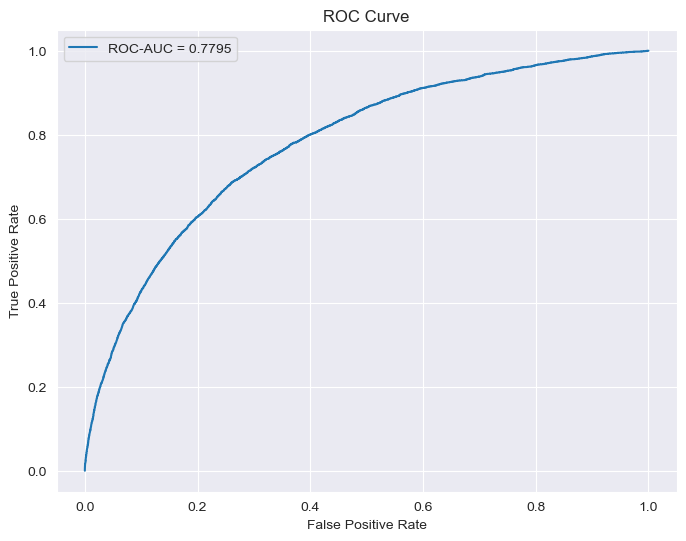

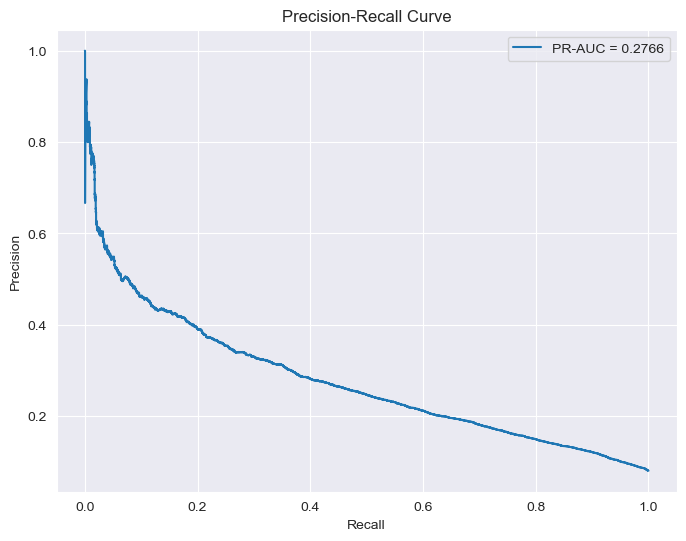

In [94]:
results_baseline = {}
cat_cols = train.drop(columns=['TARGET']).select_dtypes(include=['object']).columns

for name, info in models.items():
    print(f'Сейчас обучаем {name}')
    model = info['model']
    if name == "CatBoost":
        model.fit(x_train_for_catboost, y_train_for_catboost,cat_features=cat_cols.to_list())
        y_proba = model.predict_proba(x_test_for_catboost)[:, 1]
        y_pred = model.predict(x_test_for_catboost)
        x_train_for_catboost = x_train

    else:
        if info['scaled']:
            scaler = StandardScaler()
            x_train = scaler.fit_transform(x_train)
            x_test = scaler.transform(x_test)
            x_train_for_not_catboost = x_train
            x_test_for_not_catboost = x_test


        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_proba = model.predict_proba(x_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba)
    fpr, tpr, threshold_roc = roc_curve(y_test, y_proba)
    accuracy = accuracy_score(y_test, y_pred)
    results_baseline[name] = {
        "model": model,
        "accuracy": accuracy,
        "precisions": precisions,
        "recalls": recalls,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "fpr": fpr,
        "tpr": tpr,
        "threshold_roc": threshold_roc,
        "thresholds_pr": thresholds_pr
    }


    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


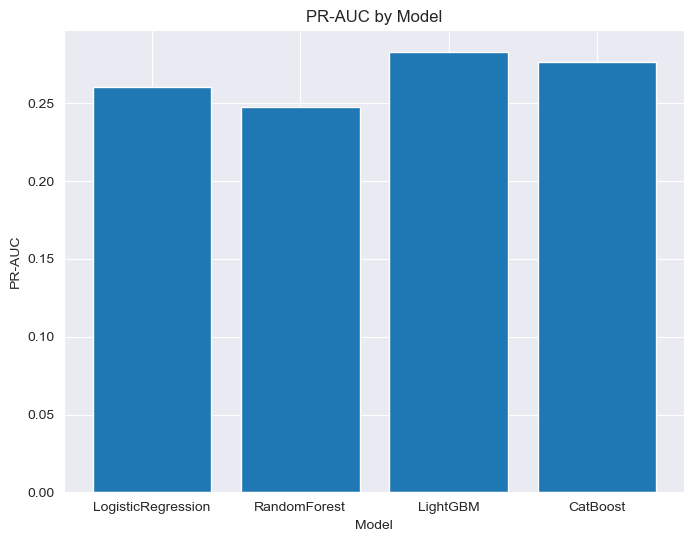

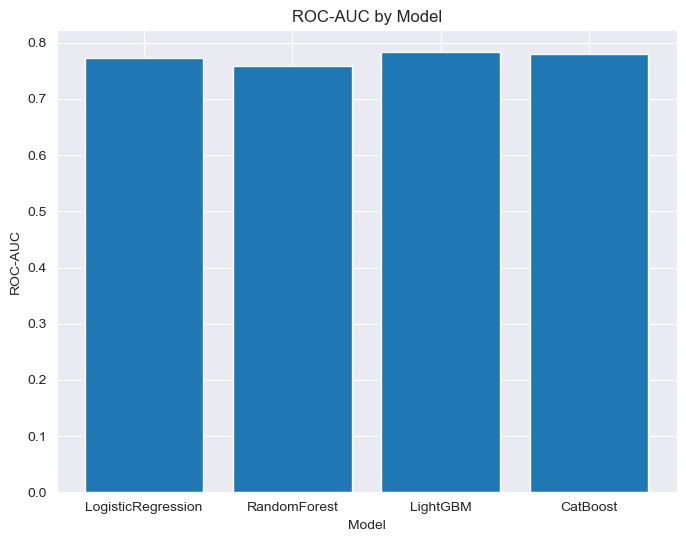

In [95]:
model_names = list(results_baseline.keys())
pr_aucs = [results_baseline[name]["pr_auc"] for name in model_names]
roc_aucs = [results_baseline[name]["roc_auc"] for name in model_names]

plt.figure(figsize=(8, 6))
plt.bar(model_names, pr_aucs)
plt.title("PR-AUC by Model")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(model_names, roc_aucs)
plt.title("ROC-AUC by Model")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.grid(True)
plt.show()

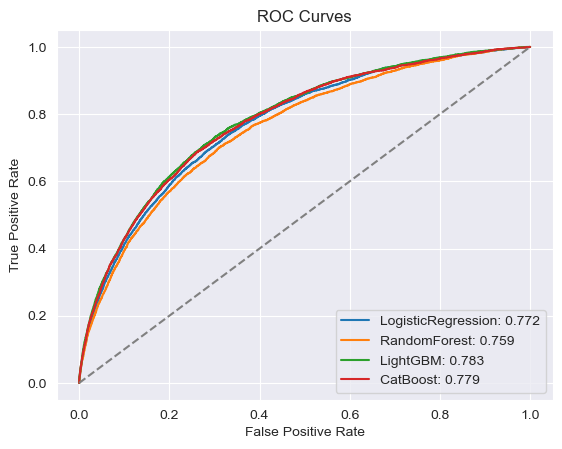

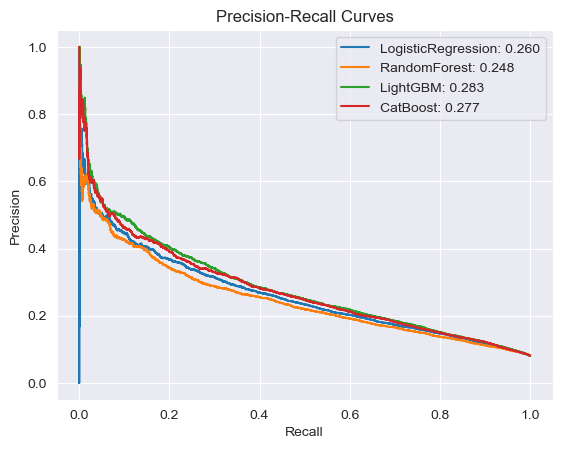

In [96]:
for name, metrics in results_baseline.items():
    plt.plot(metrics["fpr"], metrics["tpr"], label=f"{name}: {metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()
for name,metrics in results_baseline.items():
    plt.plot(metrics["recalls"],metrics['precisions'],label =f"{name}: {metrics['pr_auc']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

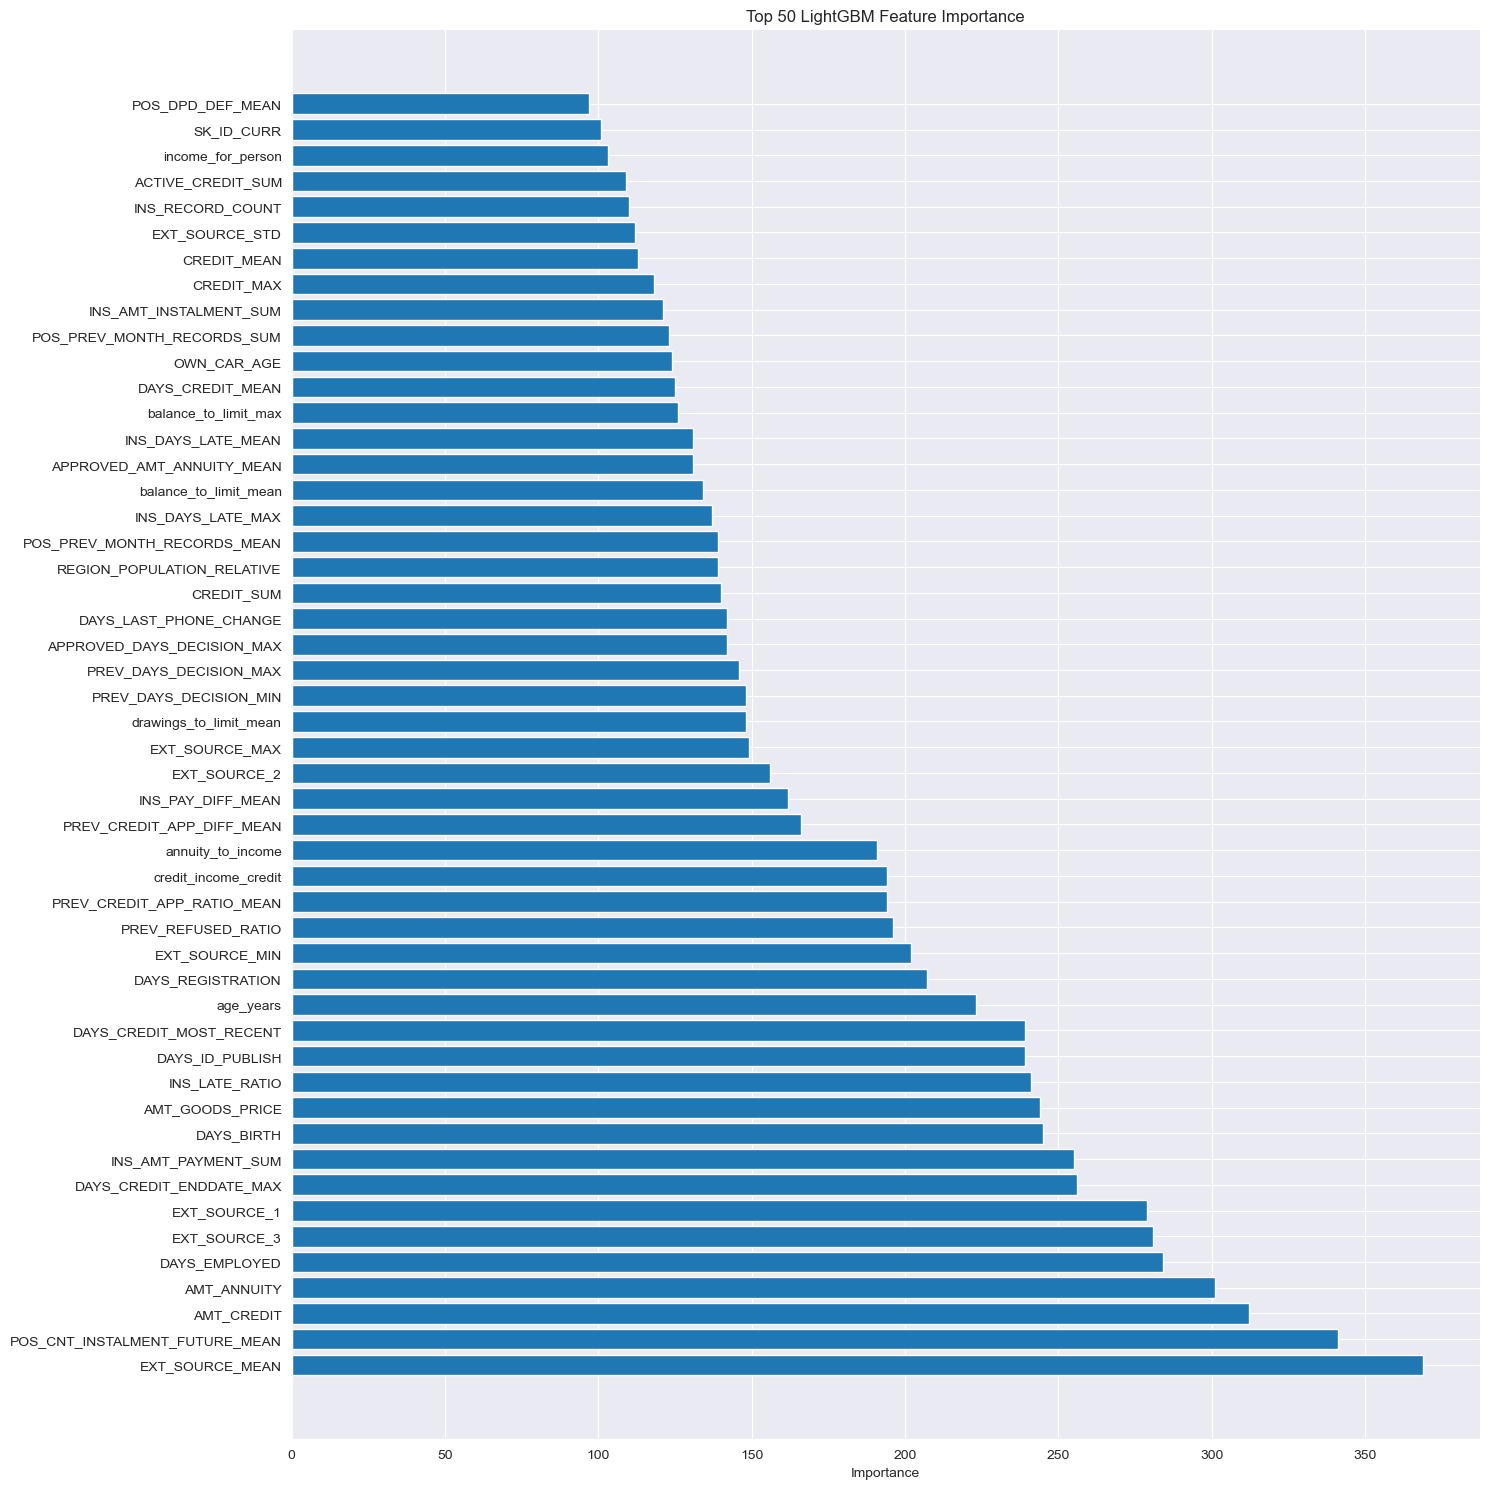

In [97]:
feature_importance = pd.DataFrame({
    'feature': x_train_copy.columns,
    'importance': models['LightGBM']['model'].feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(50).sort_values('importance', ascending=False)
plt.figure(figsize=(15, 15))
plt.barh(top_features['feature'],top_features['importance'])
plt.title('Top 50 LightGBM Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [102]:
x_train_for_not_catboost_df = pd.DataFrame(
    x_train_for_not_catboost,
    columns=x_train_copy.columns
)
x_test_for_not_catboost_df = pd.DataFrame(
    x_test_for_not_catboost,
    columns=x_train_copy.columns
)

In [108]:
x_train_copy.shape

(246008, 382)

In [111]:
import re

clean_columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in x_train_for_not_catboost_df.columns
]

x_train_for_not_catboost_df.columns = clean_columns
x_test_for_not_catboost_df.columns = clean_columns
feature_importance['feature'] = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in feature_importance['feature']
]

In [112]:
results = []

feature_counts = [1,2,10,15,20,30, 50, 80, 120,150,200,250,300,350,382]

for n in feature_counts:
    top_n_features = feature_importance.head(n)['feature'].tolist()

    x_train_top = x_train_for_not_catboost_df[top_n_features]
    x_test_top = x_test_for_not_catboost_df[top_n_features]

    model =  LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=100
        )

    model.fit(x_train_top, y_train)
    y_proba = model.predict_proba(x_test_top)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    results.append({
        'n_features': n,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000000
[LightGBM] [Debug] init for col-wise cost 0.000003 seconds, init for row-wise cost 0.000525 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Traine

In [113]:

results_df = pd.DataFrame(results)
results_df

,n_features,roc_auc,pr_auc
0,1,0.716399,0.194660
1,2,0.720115,0.199098
2,10,0.752453,0.243504
3,15,0.761823,0.254966
4,20,0.765951,0.256956
5,30,0.770895,0.261592
6,50,0.775262,0.268221
7,80,0.779909,0.273493
8,120,0.780924,0.276102
9,150,0.781780,0.280036


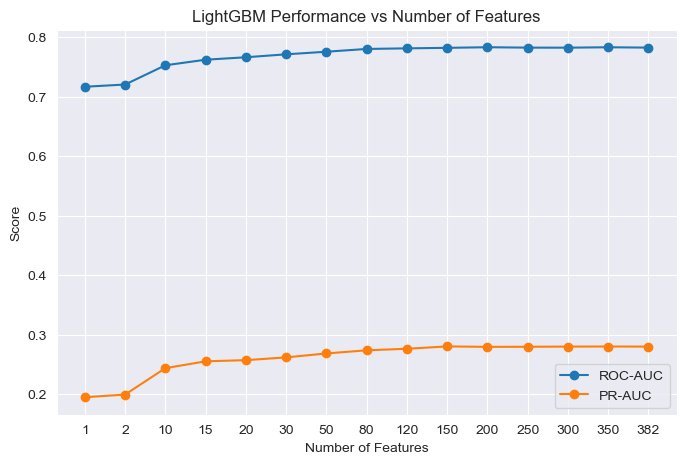

In [114]:
results_plot = results_df.copy()
results_plot['n_features'] = results_plot['n_features'].astype(str)

plt.figure(figsize=(8, 5))
plt.plot(results_plot['n_features'], results_plot['roc_auc'], marker='o', label='ROC-AUC')
plt.plot(results_plot['n_features'], results_plot['pr_auc'], marker='o', label='PR-AUC')
plt.title('LightGBM Performance vs Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()
